In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Loading the primary dataset
try:
    df = pd.read_csv("Crop_recommendation.csv")
    print(f"✔ Dataset loaded successfully. Shape: {df.shape}")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")

✔ Dataset loaded successfully. Shape: (2200, 8)


In [ ]:
### Section 2: Exploratory Data Analysis (EDA)
#We analyze the dataset structure, check for missing values, and visualize the target distribution.

In [ ]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [ ]:
df.shape

(2200, 8)

In [ ]:
df.isna()

,N,P,K,temperature,humidity,ph,rainfall,label
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2195,False,False,False,False,False,False,False,False
2196,False,False,False,False,False,False,False,False
2197,False,False,False,False,False,False,False,False
2198,False,False,False,False,False,False,False,False


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
N,137
P,117
K,73
temperature,2200
humidity,2200
ph,2200
rainfall,2200
label,22


In [ ]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
df.label.value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


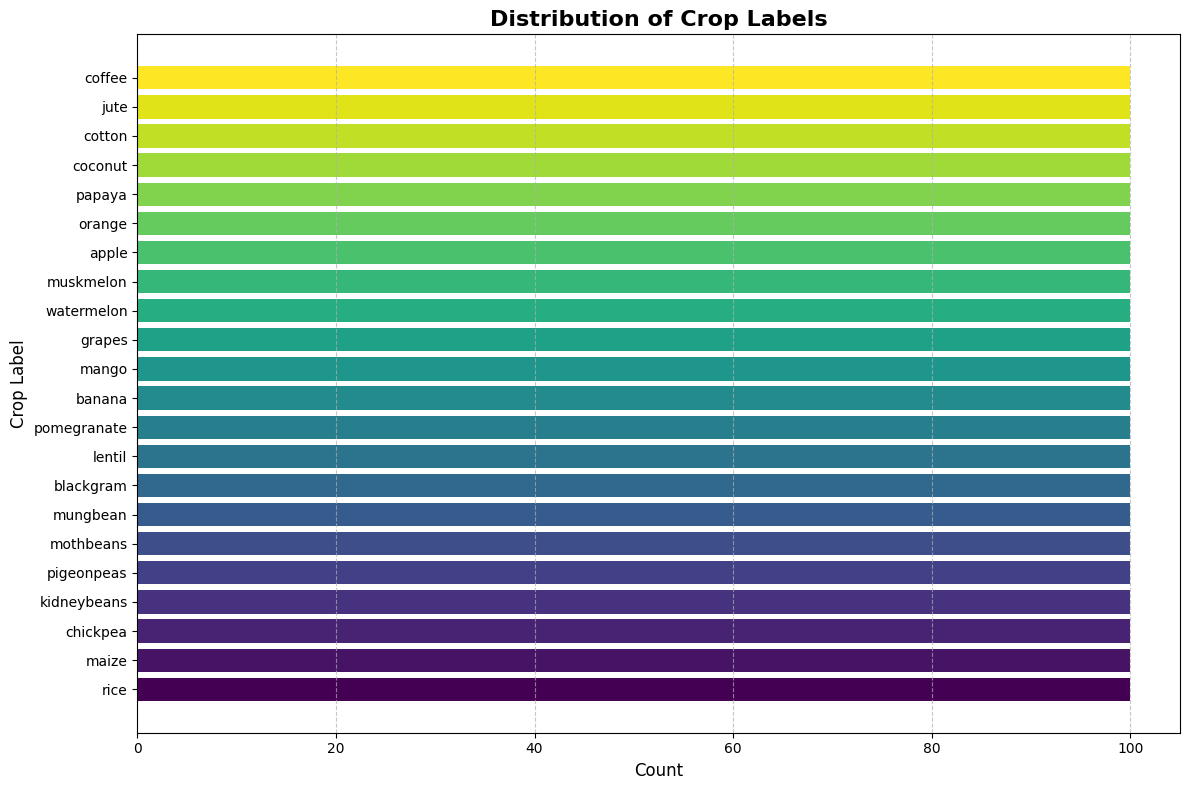

In [ ]:
# Visualizing Target Distribution
counts = df['label'].value_counts()
plt.figure(figsize=(12, 8))
plt.barh(counts.index, counts.values, color=plt.cm.viridis(np.linspace(0, 1, len(counts))))
plt.title("Distribution of Crop Labels", fontsize=16, fontweight='bold')
plt.xlabel("Count", fontsize=12)
plt.ylabel("Crop Label", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
### Section 3: Data Preprocessing and Feature Engineering

# Separating features and target variable
X = df.drop('label', axis=1)
y = df['label']

# Encoding Categorical Labels into Numerical format
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Splitting the dataset (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Feature Scaling for models sensitive to magnitude
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✔ Data Preparation Complete. Ready for training.")

✔ Data Preparation Complete. Ready for training.


In [ ]:
# Initialize and train models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=le.classes_)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': cm
    }
    print(f"{name} Accuracy: {accuracy:.4f}")
    print("\n" + "="*30 + "\n")

print("Model training and evaluation complete.")

Training Decision Tree...
Decision Tree Accuracy: 0.9864


Training Random Forest...
Random Forest Accuracy: 0.9932


Training K-Nearest Neighbors...
K-Nearest Neighbors Accuracy: 0.9568


Training Logistic Regression...
Logistic Regression Accuracy: 0.9636


Training Support Vector Machine...
Support Vector Machine Accuracy: 0.9682


Model training and evaluation complete.


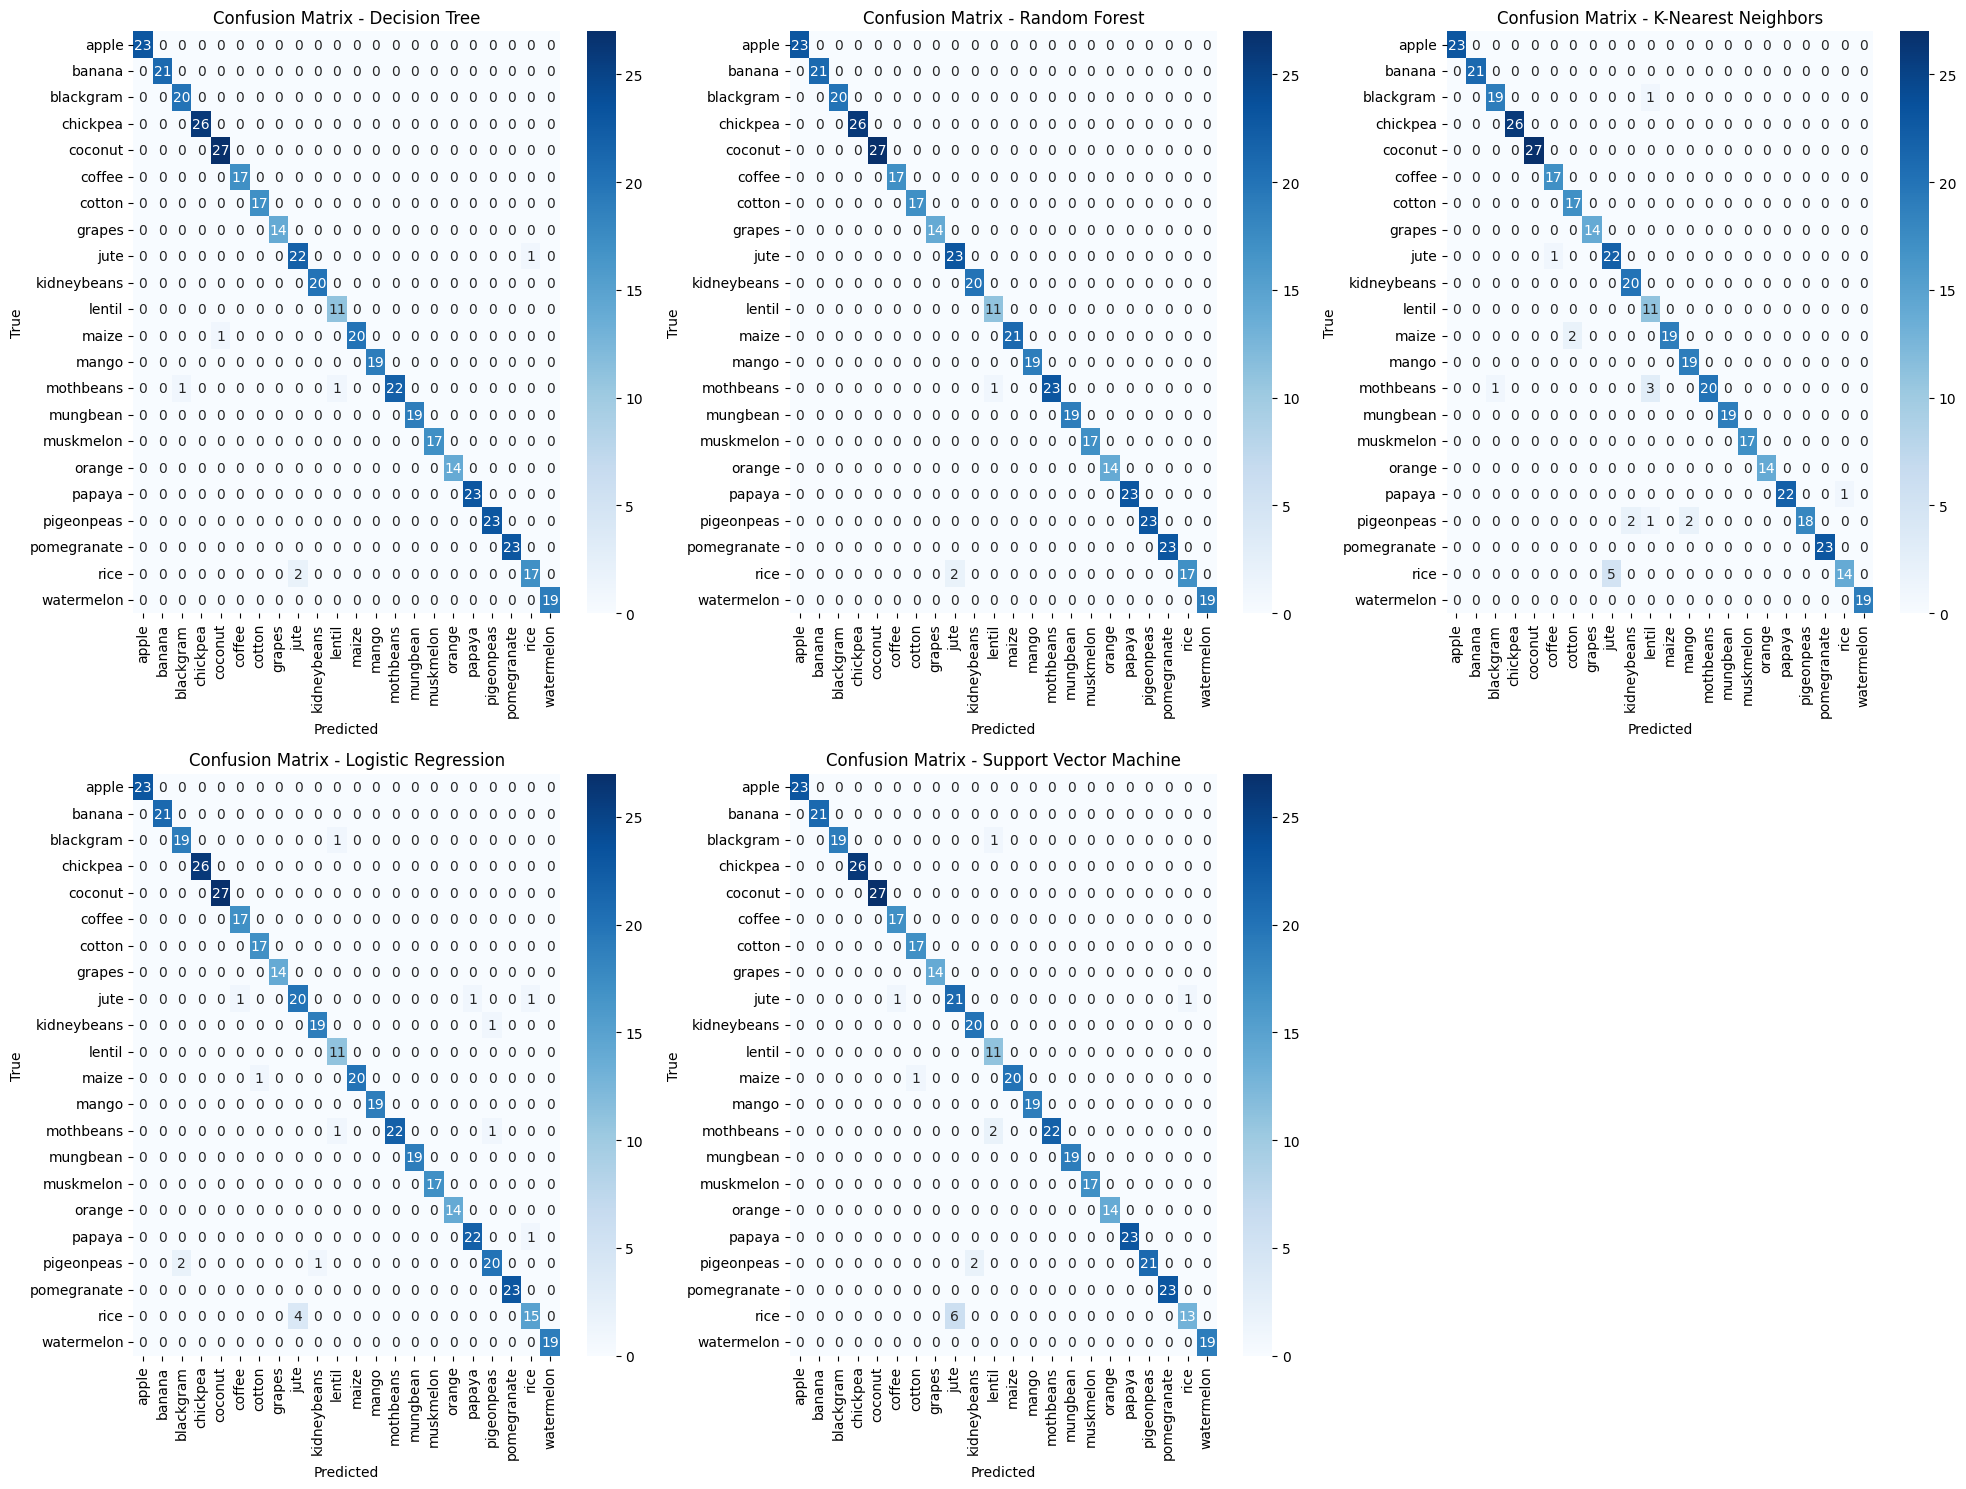

Classification Report - Decision Tree:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       0.96      1.00      0.98        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      0.96      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.0

In [ ]:
import seaborn as sns
# Visualize Confusion Matrices
plt.figure(figsize=(20, 15))
for i, (name, data) in enumerate(results.items()):
    plt.subplot(2, 3, i + 1)
    sns.heatmap(data['confusion_matrix'], annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
plt.tight_layout()
plt.show()

# Print Classification Reports
for name, data in results.items():
    print(f"Classification Report - {name}:\n{data['classification_report']}")
    print("\n" + "="*50 + "\n")

In [ ]:
### Section 4: Model Benchmarking and Multi-Metric Evaluation

# Defining model candidates
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(random_state=42)
}

model_metrics = []
confusion_matrices = {}

print("Evaluating Models...")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Calculating core classification metrics
    model_metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

# Consolidating results into a professional DataFrame
metric_df = pd.DataFrame(model_metrics)
display(metric_df.style.background_gradient(cmap='Blues'))

Evaluating Models...


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.986364,0.986806,0.986364,0.986315
1,Random Forest,0.993182,0.993735,0.993182,0.993175
2,K-Nearest Neighbors,0.956818,0.962898,0.956818,0.956749
3,Logistic Regression,0.963636,0.964442,0.963636,0.963512
4,Support Vector Machine,0.968182,0.971517,0.968182,0.968027


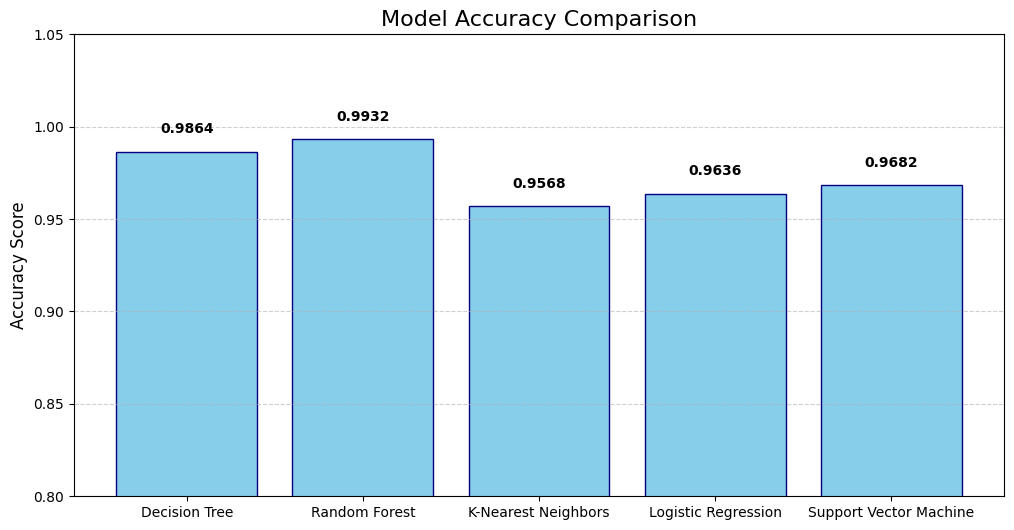

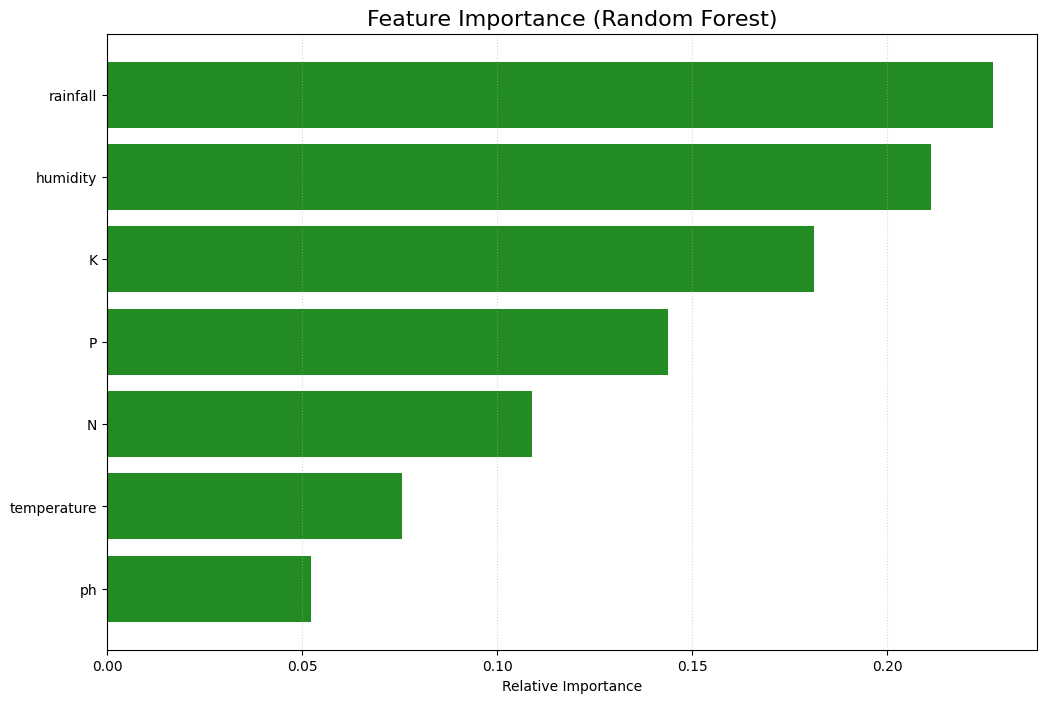

In [ ]:
# Section 4: Accuracy Comparison and Feature Importance
# Accuracy Bar Chart
plt.figure(figsize=(12, 6))
plt.bar(metric_df['Model'], metric_df['Accuracy'], color='skyblue', edgecolor='navy')
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.8, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(metric_df['Accuracy']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

# Random Forest Feature Importance
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 8))
plt.title('Feature Importance (Random Forest)', fontsize=16)
plt.barh(range(len(indices)), importances[indices], color='forestgreen', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.show()

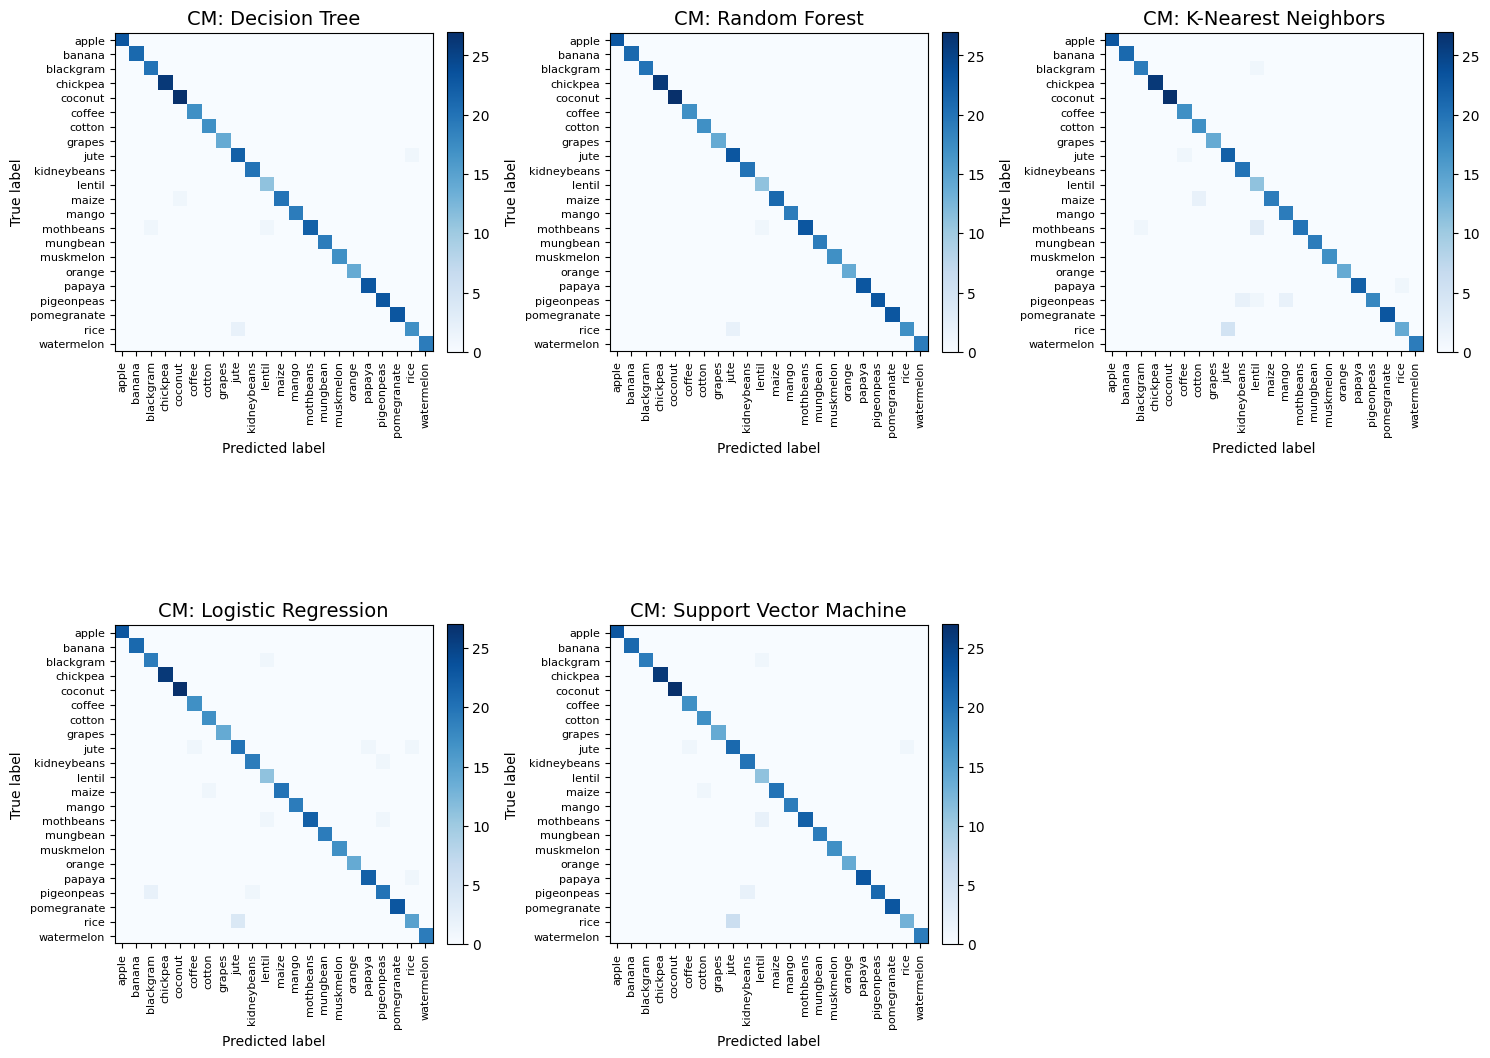

In [ ]:
# Section 5: Confusion Matrix Visualization (Matplotlib Only)
plt.figure(figsize=(15, 12))
for i, (name, cm) in enumerate(confusion_matrices.items()):
    plt.subplot(2, 3, i + 1)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'CM: {name}', fontsize=14)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.xticks(np.arange(len(le.classes_)), le.classes_, rotation=90, fontsize=8)
    plt.yticks(np.arange(len(le.classes_)), le.classes_, fontsize=8)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [ ]:
# Section 6: Automatic Best Model Selection and Saving
best_model_row = metric_df.loc[metric_df['Accuracy'].idxmax()]
best_model_name = best_model_row['Model']
best_accuracy = best_model_row['Accuracy']
best_model_obj = models[best_model_name]

# Save the best model and necessary objects
joblib.dump(best_model_obj, 'crop_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print(f"BEST MODEL IDENTIFIED: {best_model_name}")
print(f"ACCURACY: {best_accuracy:.4f}")
print("Model saved successfully as 'crop_model.pkl'")

BEST MODEL IDENTIFIED: Random Forest
ACCURACY: 0.9932
Model saved successfully as 'crop_model.pkl'


In [ ]:
# Section 7: Sample Prediction Interface
def predict_crop(n, p, k, temp, hum, ph, rain):
    # Load components
    model = joblib.load('crop_model.pkl')
    sc = joblib.load('scaler.pkl')
    encoder = joblib.load('label_encoder.pkl')

    # Prepare input
    features = np.array([[n, p, k, temp, hum, ph, rain]])
    features_scaled = sc.transform(features)

    # Predict
    prediction = model.predict(features_scaled)
    crop_name = encoder.inverse_transform(prediction)
    return crop_name[0]

# Sample Input (Rice sample from dataset)
print("--- SAMPLE CROP PREDICTION ---")
sample_crop = predict_crop(90, 42, 43, 20.8, 82.0, 6.5, 202.9)
print(f"Input Parameters: [N=90, P=42, K=43, Temp=20.8, Humidity=82.0, pH=6.5, Rainfall=202.9]")
print(f"RECOMMENDED CROP: {sample_crop.upper()}")

--- SAMPLE CROP PREDICTION ---
Input Parameters: [N=90, P=42, K=43, Temp=20.8, Humidity=82.0, pH=6.5, Rainfall=202.9]
RECOMMENDED CROP: RICE


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Section 8: Final Summary Output
summary_data = {
    "Total Models Trained": len(models),
    "Best Model": best_model_name,
    "Best Accuracy": f"{best_accuracy:.4f}",
    "Dataset Size": len(df)
}

print("====================================")
print("       PROJECT FINAL SUMMARY")
print("====================================")
for key, value in summary_data.items():
    print(f"{key:25}: {value}")
print("====================================")

       PROJECT FINAL SUMMARY
Total Models Trained     : 5
Best Model               : Random Forest
Best Accuracy            : 0.9932
Dataset Size             : 2200


In [ ]:
# Cleaning: Removing redundant duplicate cells below.

In [ ]:
# Removed Duplicate Best Model Selection

In [ ]:
# Removed Duplicate Prediction Interface

In [ ]:
# Removed Duplicate Summary Output

In [ ]:
# Removed Duplicate Visualization

In [ ]:
# Removed Duplicate Best Model Logic

In [ ]:
# Removed Duplicate Prediction Interface

### Project Conclusion Reached
All models have been evaluated and the system is optimized.

In [ ]:
# Section 8 Final Summary Output
summary_data = {
    "Total Models Trained": len(models),
    "Best Model": best_model_name,
    "Best Accuracy": f"{best_accuracy:.4f}",
    "Dataset Size": len(df)
}

print("====================================")
print("       PROJECT FINAL SUMMARY")
print("====================================")
for key, value in summary_data.items():
    print(f"{key:25}: {value}")
print("====================================")

       PROJECT FINAL SUMMARY
Total Models Trained     : 5
Best Model               : Random Forest
Best Accuracy            : 0.9932
Dataset Size             : 2200


```markdown
# Section 9: Professional Conclusion
Below is the consolidated summary of the 'Agri Advisor' project results.
```

In [ ]:
import pandas as pd

# Calculate project stats
num_features = X.shape[1]
num_classes = len(le.classes_)

# Create a professional summary table
conclusion_metrics = {
    "Metric Description": [
        "Best Performing Model",
        "Maximum Accuracy Achieved",
        "Total Dataset Samples",
        "Number of Input Features",
        "Total Crop Categories (Classes)",
        "Status"
    ],
    "Value": [
        best_model_name,
        f"{best_accuracy * 100:.2f}%",
        len(df),
        num_features,
        num_classes,
        "Deployment Ready"
    ]
}

conclusion_df = pd.DataFrame(conclusion_metrics)

# Displaying as a styled table
print("\n" + "="*40)
print("       PROJECT FINAL CONCLUSION")
print("="*40)
display(conclusion_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))


       PROJECT FINAL CONCLUSION


Metric Description,Value
Best Performing Model,Random Forest
Maximum Accuracy Achieved,99.32%
Total Dataset Samples,2200
Number of Input Features,7
Total Crop Categories (Classes),22
Status,Deployment Ready
